In [59]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

plt.rcParams["font.family"] = "serif"

In [60]:
# PHYSICAl CONSTANTS

M_E_SI = 9.1093837015e-31 # electron mass in kg
M_E = 0.511 # electron mass in MeV/c^2
Q_E_SI = -1.602176634e-19 # electron charge in C
Q_E = -1. # electron charge in e
EPSILON_0 = 5.5263494e13  # vacuum permittivity in in e/(MV*m)
C_SI = 299792458 # speed of light in m/s
C = 1. # speed of light in c

# HYPERPARAMETERS

LENGTH_PRIOR = 0.5 # length of prior region to be modeled in m
LENGTH_D = 0.25 # length of drift chamber in m
LENGTH_E = 3.75 # length of electric field chamber in m
LENGTH_POSTERIOR = 2.5 # length of posterior region to be modeled in m

RADIUS_X = 0.1 # width of model space in x direction in m
RADIUS_Y = 0.1 # width of model space in y direction in m


ENERGY_0 = 1e-2 # initial kinetic energy of reference particle in MeV


SIGMA_X = 1e-3 # standard deviation of initial x position in m
SIGMA_Y = 1e-3 # standard deviation of initial y position in m
SIGMA_Z = 0.1 # standard deviation of initial z position in m

SIGMA_PX_BG = 1e-9 # standard deviation of initial x momentum in 1 (betagamma)
SIGMA_PY_BG = 1e-9 # standard deviation of initial y momentum in 1 (betagamma)
SIGMA_PZ_BG = 1e-2 # standard deviation of initial z momentum in 1 (betagamma)


E_Z = -1. # electric field strength in MV/m

N_PARTICLES = 32*32*32 # number of macro particles
TOTAL_CHARGE_SI = -1e-9 # total bunch charge in C


# DERIVED QUANTITIES

Z_START = -LENGTH_PRIOR # start of model space
Z_0 = Z_START + LENGTH_PRIOR # initial z position of particles
Z_1 = Z_START + LENGTH_PRIOR + LENGTH_D # z position of end of drift chamber = start of electric field chamber
Z_2 = Z_START + LENGTH_PRIOR + LENGTH_D + LENGTH_E # z position of end of electric field chamber
Z_END = Z_2 + LENGTH_POSTERIOR # end of model space

GAMMA_0 = (ENERGY_0 + M_E) / M_E # initial Lorentz factor of reference particle
BETA_0 = np.sqrt(1 - 1 / GAMMA_0**2) # initial beta of reference particle
PZ_0 = BETA_0 * GAMMA_0 * M_E # initial momentum of reference particle in MeV/c

POSITION_0 = (0., 0., Z_0) # initial position (of reference particle) in m
MOMENTUM_0 = (0., 0., PZ_0) # initial momentum in MeV/c

BG_to_P = lambda bg: bg * M_E # function to transform momentum from betagamma to particle units

POSITION_SIGMA = (SIGMA_X, SIGMA_Y, SIGMA_Z) # in m
MOMENTUM_SIGMA = (BG_to_P(SIGMA_PX_BG), BG_to_P(SIGMA_PY_BG), BG_to_P(SIGMA_PZ_BG)) # in MeV/c


N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI / Q_E_SI) # number of real electrons in the bunch
MACRO_WEIGHT = N_REAL_PARTICLES / N_PARTICLES 

M_MACRO = M_E * MACRO_WEIGHT
Q_MACRO = Q_E * MACRO_WEIGHT

### Helper Functions

In [61]:
def gamma(p):
    '''
    Calculate relativistic gamma factor from particle momentum

    Returns scalar
    '''
    p_squared = np.sum(p**2)
    gamma = np.sqrt(1. + (p_squared / M_E**2))

    return gamma

def v_SI(p):
    return (p / (gamma(p) * M_E)) * C_SI 

    
def p_to_betagamma(p):
    '''
    Transform momentum from particle units [MeV/c] to dimensionless beta*gamma unit [1]

    Returns np.array of shape (N_P,1)
    '''

    return p / M_E


def gamma_particles(momentum_particles):
    '''
    Calculate relativistic gamma factor from particle momentum

    Returns np.array of shape (N_P,1)
    '''
    p_squared = np.sum(momentum_particles**2, axis=1, keepdims=True)
    gamma = np.sqrt(1. + (p_squared / M_E**2))

    return gamma
    

# 1 Particle

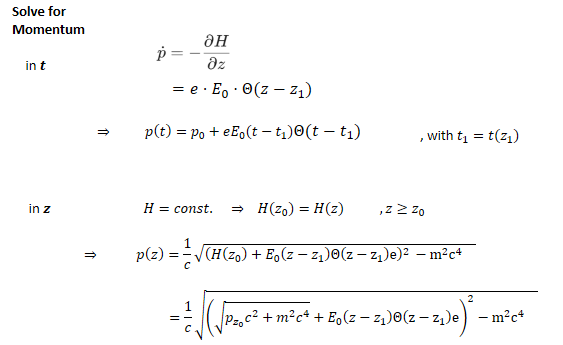

In [62]:
def p_of_t_1d(t, p_0):
    t_1 = Z_1 / v_SI(p_0)
    
    if t < t_1:
        return p_0
    else:
        return p_0 + Q_E * E_Z * (t - t_1)
    
def p_of_z_1d(z, p_0):
    if z < Z_1:
        return (1/C) * np.sqrt((p_0**2*C**2 + M_E**2*C**4) - M_E**2 * C**4)
    if z >= Z_1:
        return (1/C) * np.sqrt((np.sqrt(p_0**2*C**2 + M_E**2*C**4) + Q_E*E_Z*(z-Z_1) )**2 - M_E**2 * C**4)

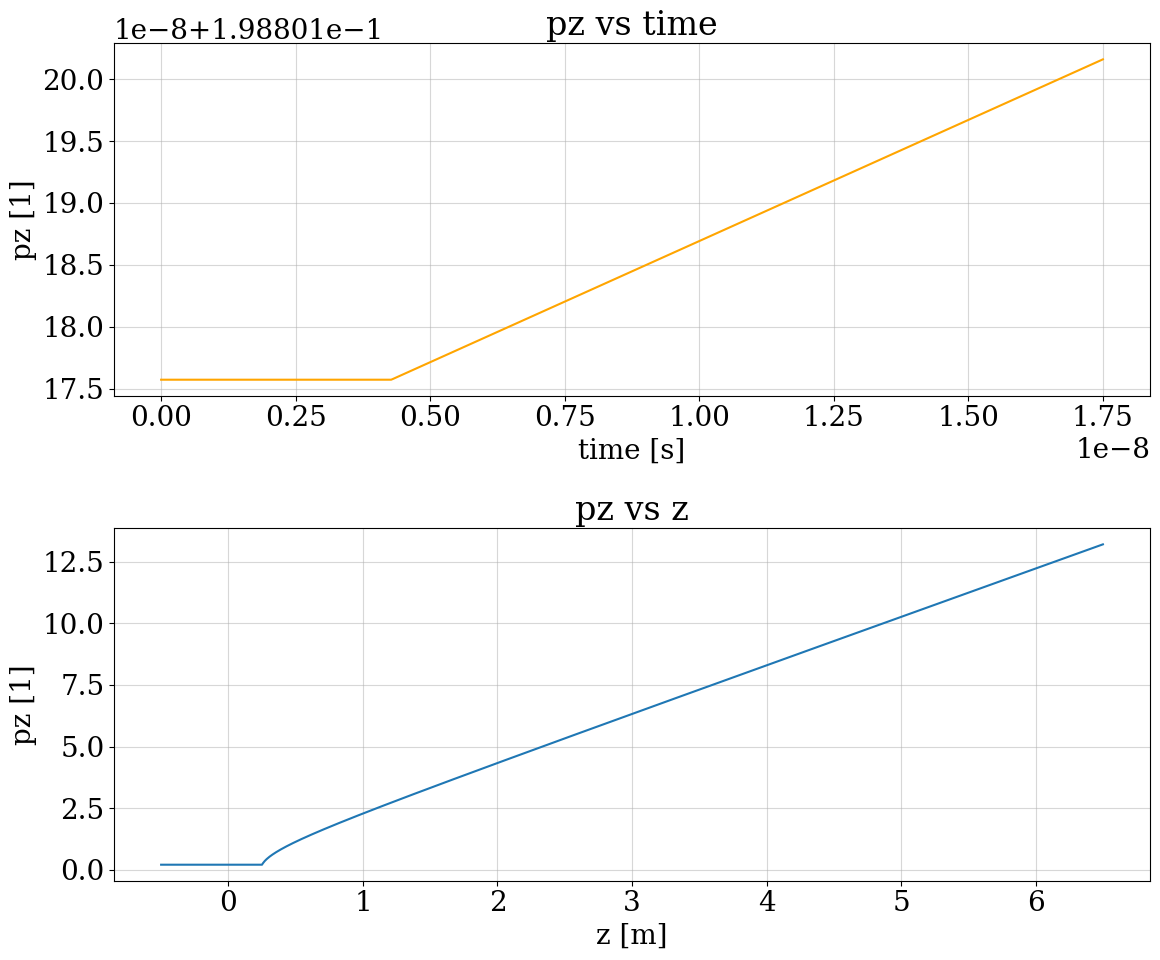

In [63]:
fig, axes = plt.subplots(2, figsize=(12, 10))

t_end = 1.75e-8
p_0 = MOMENTUM_0[2]
times = np.linspace(0., t_end, 1000)
momenta_vs_time = np.array([p_of_t_1d(t, p_0) for t in times]) 

axes[0].plot(times, p_to_betagamma(momenta_vs_time), color='orange')
axes[0].set_xlabel('time [s]')
axes[0].set_ylabel(f'pz [1]')
axes[0].set_title(f'pz vs time')
axes[0].grid()

positions = np.linspace(Z_START, Z_END, 1000)
momenta_vs_position = np.array([p_of_z_1d(z, p_0) for z in positions])

axes[1].plot(positions, p_to_betagamma(momenta_vs_position))
axes[1].set_xlabel('z [m]')
axes[1].set_ylabel(f'pz [1]')
axes[1].set_title(f'pz vs z')
axes[1].grid()

plt.tight_layout()
plt.show()


# N Particles

### 1D

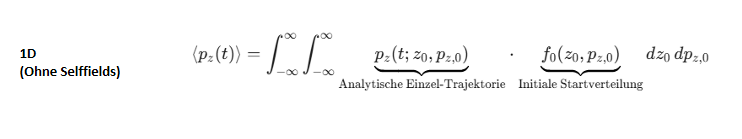
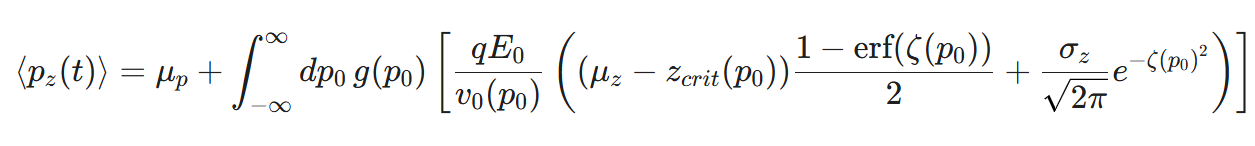 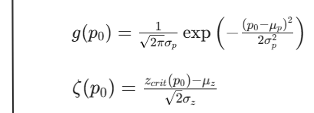
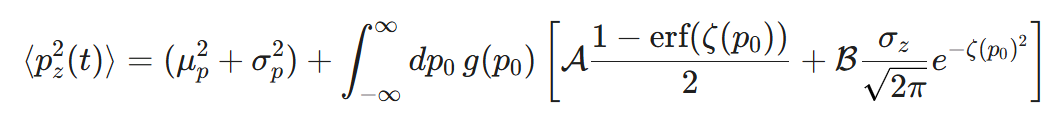
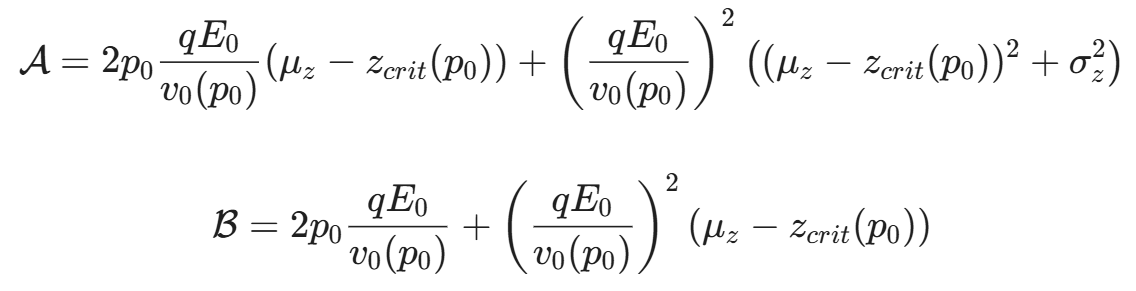


In [64]:
from scipy.integrate import quad
from scipy.special import erf

def calc_g0(p0, mu_p0, sigma_p0):
    return 1/(np.sqrt(2*np.pi)*sigma_p0) * np.exp(- (p0 - mu_p0)**2 / (2*sigma_p0**2))

def calc_z_crit(t, v0_SI):
    return Z_1 - v0_SI*t

def calc_zeta(z_crit, mu_z0, sigma_z0):
    return (z_crit - mu_z0) / (np.sqrt(2) * sigma_z0)

def mu_p_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0):
 
    def integrand(p0):
        g0 = calc_g0(p0, mu_p0, sigma_p0)
        
        v0_SI = v_SI(p0)
        v0 = v0_SI / C_SI
        z_crit = calc_z_crit(t, v0_SI)
        zeta = calc_zeta(z_crit, mu_z0, sigma_z0)
        
        bracket = (Q_E*E_Z/v0) * (
            (mu_z0 - z_crit) * ((1.0 - erf(zeta)) / 2.0) + 
            (sigma_z0 / np.sqrt(2*np.pi)) * np.exp(-zeta**2)
        )

        return g0 * bracket
    
    # integral, error = quad(integrand, -np.inf, np.inf)
    integral, error = quad(integrand, mu_p0 - 10.0*sigma_p0, mu_p0 + 10.0*sigma_p0) # restrict integration limits to yields finer resolution

    # we can pull p_0 out of the integral, yielding a constant mu_p0 
    return mu_p0 + integral

def mu_p_squared_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0):

    def integrand(p0):
        g0 = calc_g0(p0, mu_p0, sigma_p0)
        
        v0_SI = v_SI(p0)
        v0 = v0_SI / C_SI
        z_crit = calc_z_crit(t, v0_SI)
        zeta = calc_zeta(z_crit, mu_z0, sigma_z0)

        term_A = 2 * p0 * (Q_E*E_Z/v0) * (mu_z0-z_crit) + (Q_E*E_Z/v0)**2 * ((mu_z0-z_crit)**2 + sigma_z0**2)
        term_B = 2 * p0 * (Q_E*E_Z/v0) + (Q_E*E_Z/v0)**2 * (mu_z0-z_crit)

        bracket = term_A * (1-erf(zeta))/2 + term_B * (sigma_z0 / np.sqrt(2*np.pi)) * np.exp(-zeta**2)

        return g0*bracket

    # integral, error = quad(integrand, -np.inf, np.inf)
    integral, error = quad(integrand, mu_p0 - 10.0*sigma_p0, mu_p0 + 10.0*sigma_p0) # restrict integration limits to yields finer resolution

    # we can pull p_0^2 out of the integral, yielding a constant term: 
    term_p0_squared = mu_p0**2  + sigma_p0**2

    return term_p0_squared + integral

def rms_p_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0):
    mu_p0_t =  mu_p_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0)
    mu_p0_squared_t = mu_p_squared_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0)

    return np.sqrt(mu_p0_squared_t - mu_p0_t**2)


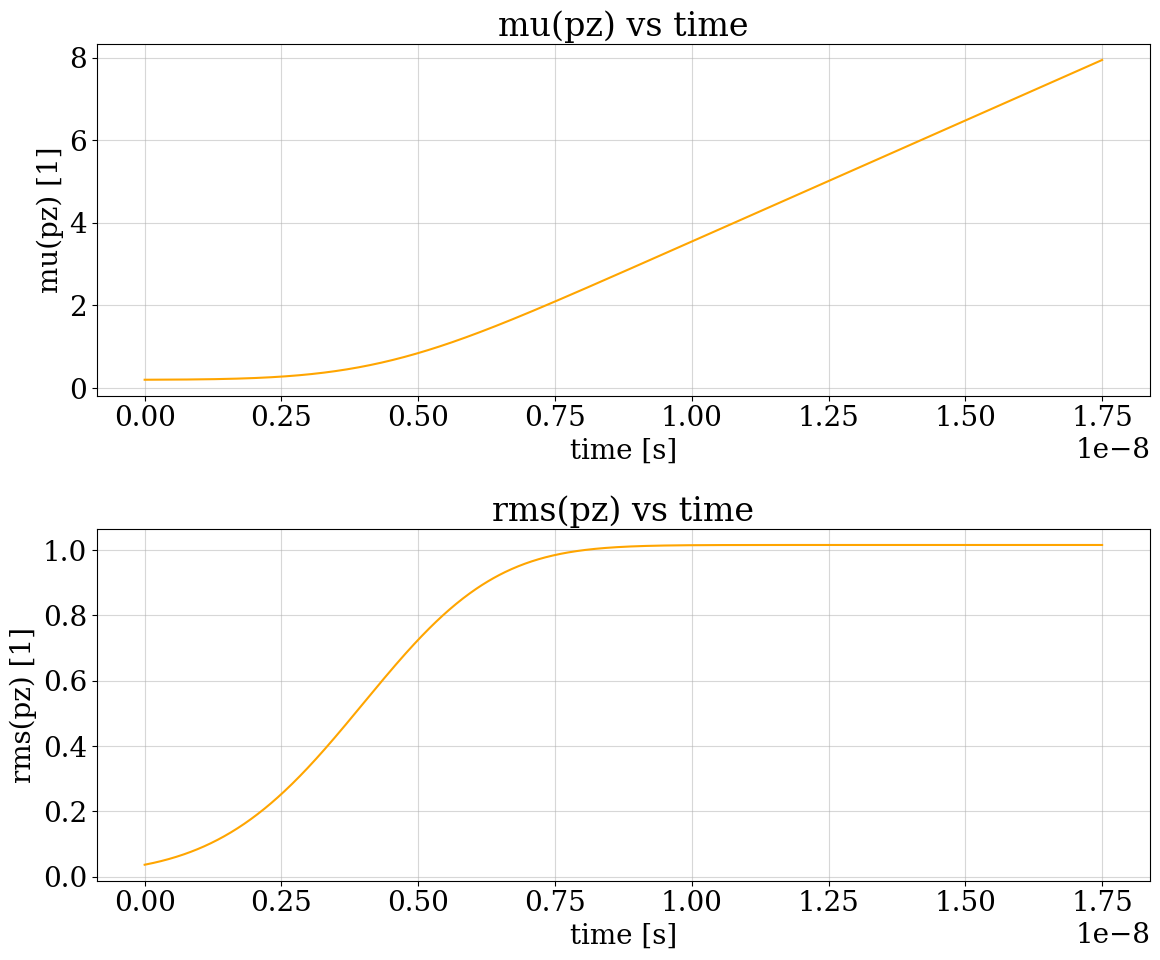

In [65]:
fig, axes = plt.subplots(2, figsize=(12, 10))


times = np.linspace(0., t_end, 1000)
mu_z0, sigma_z0, mu_p0, sigma_p0 = POSITION_0[2], POSITION_SIGMA[2], MOMENTUM_0[2], MOMENTUM_SIGMA[2]


mu_p_vs_time = np.array([mu_p_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0) for t in times])
axes[0].plot(times, p_to_betagamma(mu_p_vs_time), color='orange')
axes[0].set_xlabel('time [s]')
axes[0].set_ylabel(f'mu(pz) [1]')
axes[0].set_title(f'mu(pz) vs time')
# axes[0].ticklabel_format(useOffset=False, style='plain')
axes[0].grid()

rms_p_vs_time = np.array([rms_p_of_t_1d(t, mu_z0, sigma_z0, mu_p0, sigma_p0) for t in times])
axes[1].plot(times, p_to_betagamma(rms_p_vs_time), color='orange')
axes[1].set_xlabel('time [s]')
axes[1].set_ylabel(f'rms(pz) [1]')
axes[1].set_title(f'rms(pz) vs time')
axes[1].grid()

plt.tight_layout()
plt.show()